In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(project_root)

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt

import model as md
import view as vw

from model.relevant_methods import phase_methods

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm


In [2]:
# Параметры
F_main_real = 4.91919192e+05
phase_real = 4.59494949e+01
fs_mult = 1.82828283e+01
duration_T = 1.42000000e+02
gen_unstable = 1.32181818e+00
bins=12
SNR = 50 # dB

# Временная сетка
duration = duration_T / F_main_real
fs = F_main_real * fs_mult
t = np.linspace(0, duration, int(duration * fs))

# 1. Общая фаза
phase = md.generate_common_phase(
    t,
    F_main_real,
    gen_unstable,
    phase0_deg=0
)

# 2. Сигналы с заданной фазовой разницей
U, I = md.generate_signals_from_phase(
    phase,
    phase_diff_deg=phase_real
)

# 3. Добавляем шум
U = md.add_SNR(U, SNR)#
I = md.add_SNR(I, SNR)

U=md.adc_quantize(U,int(bins),1)
I=md.adc_quantize(I,int(bins),1)

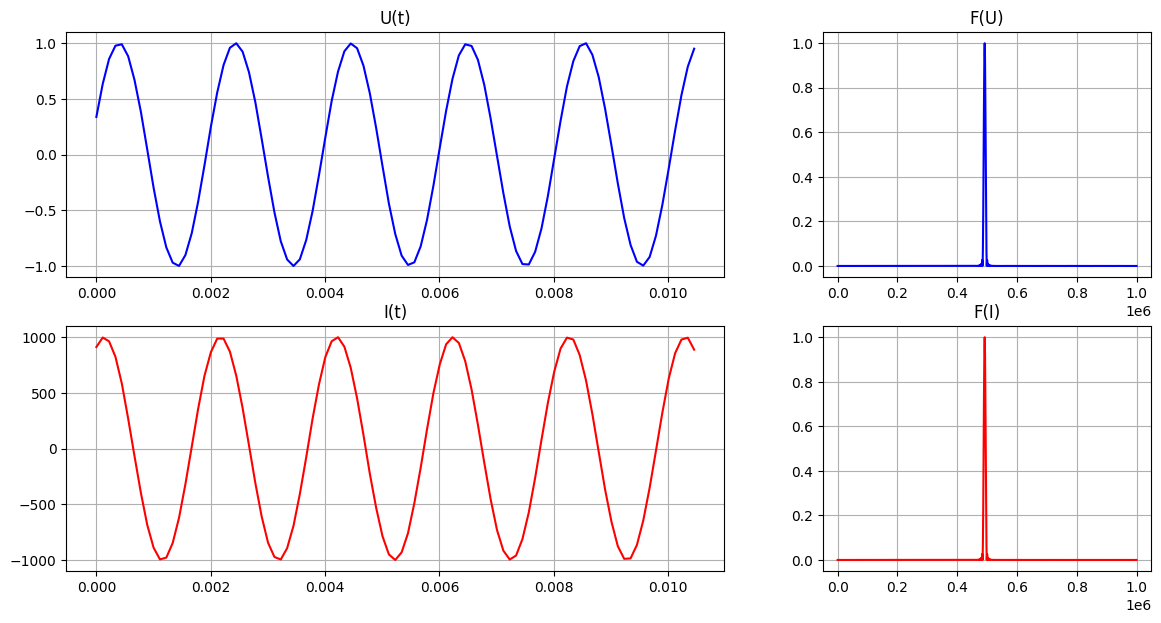

In [3]:
F,V = md.get_spectrum3(t,U)
F_peak_calc = F_main_real#F[np.argmax(V)]
T=1/F_peak_calc
T_counts=md.convert_to_counts(t,T)
window=T_counts*5

vw.show_I_U_2(t,I,U,0,window)

In [4]:
#t_f, U_f=md.filter_butter_bandpass(t,U,F_peak_calc,100e3,5)
#t_f, I_f=md.filter_butter_bandpass(t,I,F_peak_calc,100e3,5)
#
#vw.show_I_U_2(t_f,I_f, U_f,0,window)

In [5]:
for i in range(0,len(phase_methods),1):
    phase=phase_methods[i](t, I,U, F_peak_calc)
    div=abs(phase_real-phase)
    print(phase_methods[i].__name__)
    print (" phase extimated=",phase," phase div=",div)


get_phase_MP
 phase extimated= 46.24006578469795  phase div= 0.29057088469794934
get_phase_ZCRR
 phase extimated= 45.949048201990294  phase div= 0.0004466980097035389
get_phase_FFT
 phase extimated= 45.945791212039325  phase div= 0.0037036879606731077
get_phase_HB
 phase extimated= 45.956907352671614  phase div= 0.007412452671616165
get_phase_XCOR
 phase extimated= 45.94315573227207  phase div= 0.006339167727929862
get_phase_LI
 phase extimated= 44.98598907000282  phase div= 0.9635058299971746
get_phase_SWFR
 phase extimated= 45.942526803074884  phase div= 0.006968096925113798
